In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\Nidhi\Downloads\Package.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

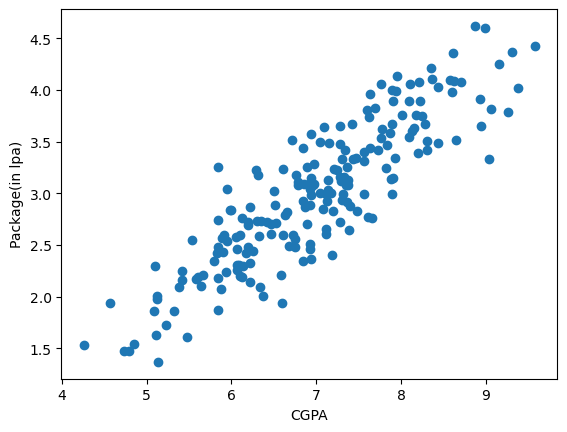

In [4]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [5]:
#Selecting specific columns
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(X_train,y_train)

LinearRegression()

In [10]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [11]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [12]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

C:\Users\Nidhi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package(in lpa)')

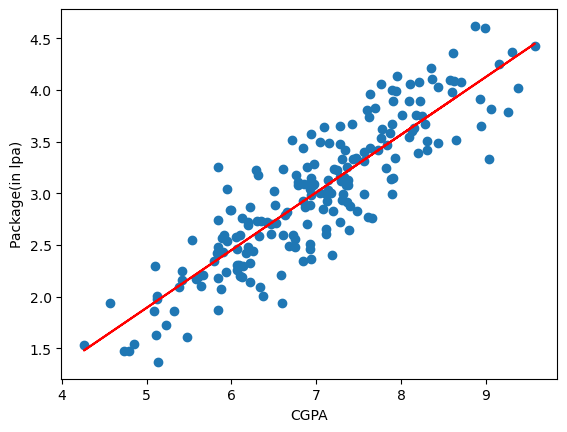

In [13]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [14]:
m = lr.coef_

In [15]:
b = lr.intercept_

In [16]:
# y = mx + b

m * 8.58 + b

array([3.89111601])

In [17]:
m * 9.5 + b

array([4.40443183])

In [18]:
m * 100 + b

array([54.89908542])

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [20]:
data = pd.read_csv(r"C:\Users\Nidhi\Downloads\auto-mpg.csv")

In [21]:
data.shape

(398, 9)

In [22]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [23]:
data = data.drop('car name', axis=1)

In [24]:
data['origin'] = data['origin'].replace({1: 'america', 2: 'europe', 3: 'asia'})
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,america
1,15.0,8,350.0,165,3693,11.5,70,america
2,18.0,8,318.0,150,3436,11.0,70,america
3,16.0,8,304.0,150,3433,12.0,70,america
4,17.0,8,302.0,140,3449,10.5,70,america


In [25]:
data = pd.get_dummies(data, columns=['origin'])
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130,3504,12.0,70,True,False,False
1,15.0,8,350.0,165,3693,11.5,70,True,False,False
2,18.0,8,318.0,150,3436,11.0,70,True,False,False
3,16.0,8,304.0,150,3433,12.0,70,True,False,False
4,17.0,8,302.0,140,3449,10.5,70,True,False,False


In [26]:
data.describe()

,mpg,cylinders,displacement,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000


In [27]:
data.dtypes

mpg               float64
cylinders           int64
displacement      float64
horsepower         object
weight              int64
acceleration      float64
model year          int64
origin_america       bool
origin_asia          bool
origin_europe        bool
dtype: object

In [28]:
hpIsDigit = pd.DataFrame(data.horsepower.str.isdigit())


In [29]:
data[hpIsDigit['horsepower'] == False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,?,2046,19.0,71,True,False,False
126,21.0,6,200.0,?,2875,17.0,74,True,False,False
330,40.9,4,85.0,?,1835,17.3,80,False,False,True
336,23.6,4,140.0,?,2905,14.3,80,True,False,False
354,34.5,4,100.0,?,2320,15.8,81,False,False,True
374,23.0,4,151.0,?,3035,20.5,82,True,False,False


In [30]:
data = data.replace('?', np.nan)
data[hpIsDigit['horsepower'] == False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_america,origin_asia,origin_europe
32,25.0,4,98.0,NaN,2046,19.0,71,True,False,False
126,21.0,6,200.0,NaN,2875,17.0,74,True,False,False
330,40.9,4,85.0,NaN,1835,17.3,80,False,False,True
336,23.6,4,140.0,NaN,2905,14.3,80,True,False,False
354,34.5,4,100.0,NaN,2320,15.8,81,False,False,True
374,23.0,4,151.0,NaN,3035,20.5,82,True,False,False


In [31]:
data['horsepower'] = data['horsepower'].astype('float64')

In [32]:
data.median()


mpg                 23.0
cylinders            4.0
displacement       148.5
horsepower          93.5
weight            2803.5
acceleration        15.5
model year          76.0
origin_america       1.0
origin_asia          0.0
origin_europe        0.0
dtype: float64

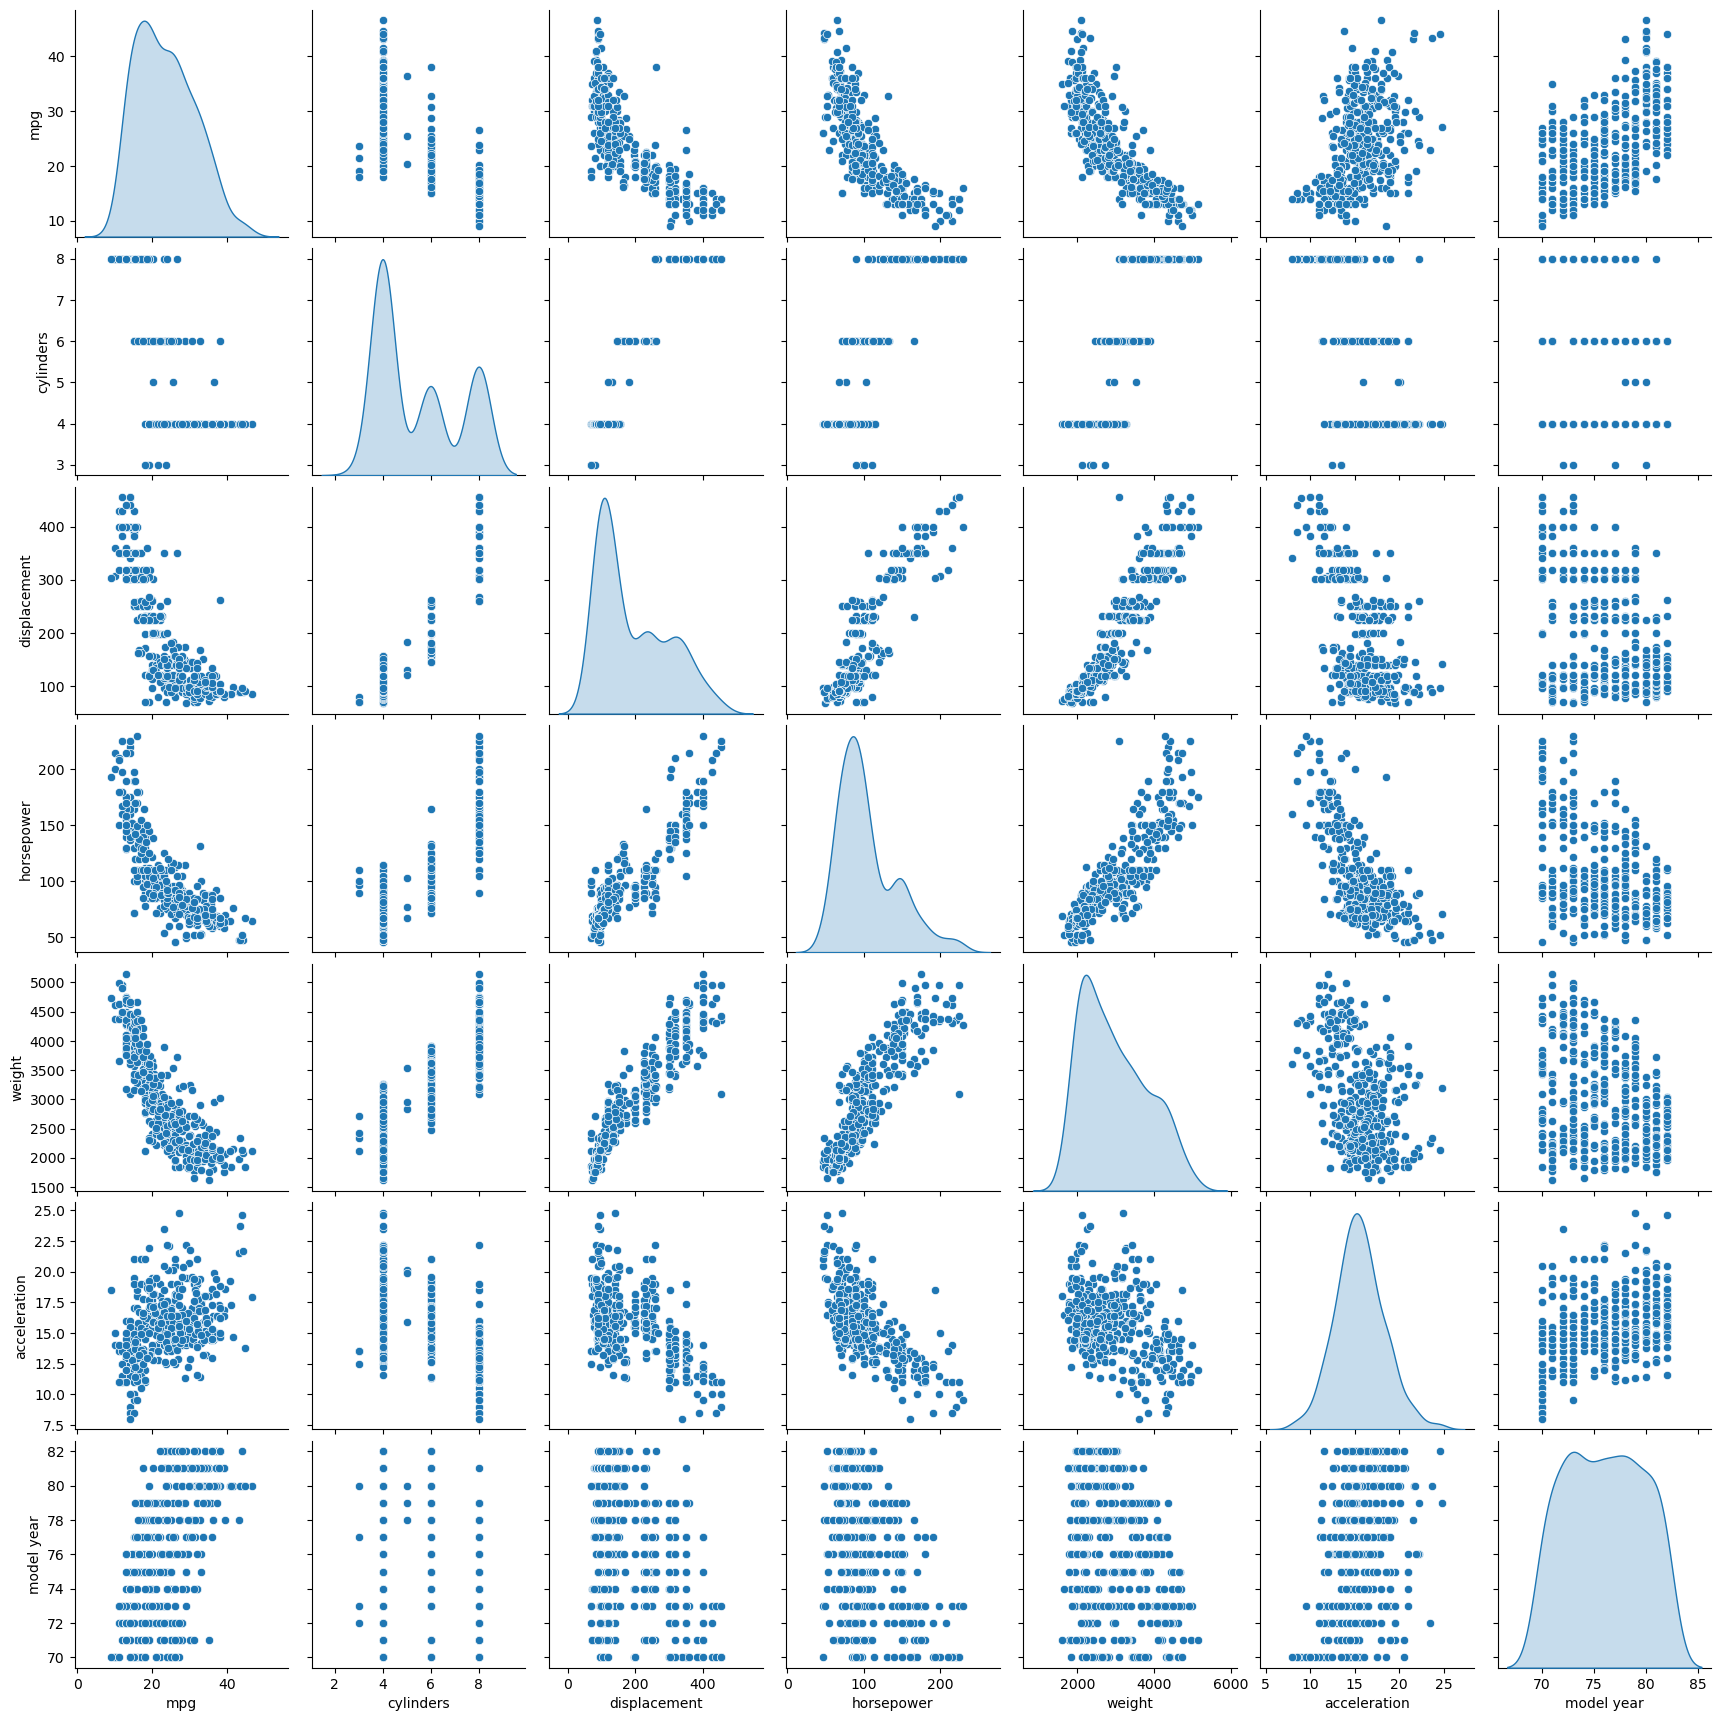

In [33]:
data_attr = data.iloc[:, 0:7]
sns.pairplot(data_attr, diag_kind='kde')

In [34]:
X = data.drop(['mpg','origin_europe'], axis=1)
y = data[['mpg']]


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [36]:


train_data = pd.concat([X_train, y_train], axis=1)
train_data = train_data.dropna()


X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]


regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

LinearRegression()

In [37]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for cylinders is -0.47502990976188253
The coefficient for displacement is 0.028782246688013022
The coefficient for horsepower is -0.026118801826782525
The coefficient for weight is -0.007034625344638226
The coefficient for acceleration is 0.04143958672583126
The coefficient for model year is 0.8338211030279516
The coefficient for origin_america is -2.831319544843373
The coefficient for origin_asia is -0.4341466104834936


In [38]:
intercept = regression_model.intercept_
print("The intercept for our model is {}".format(intercept))

The intercept for our model is -17.889939861972465


In [39]:
regression_model.score(X_train, y_train)

0.8142843729463382

In [40]:
test_data = pd.concat([X_test, y_test], axis=1)
test_data = test_data.dropna()

X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

print(regression_model.score(X_test, y_test))

0.8415400025463291


In [41]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.fit_transform(X_test)

poly_clf = linear_model.LinearRegression()

poly_clf.fit(X_train2, y_train)

y_pred = poly_clf.predict(X_test2)

print(poly_clf.score(X_train2, y_train))

0.9026699263401001


In [42]:
print(poly_clf.score(X_test2, y_test))

0.8620610379579381


In [43]:
print(X_train.shape)
print(X_train2.shape)

(273, 8)
(273, 37)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [16]:
df = pd.read_csv(r"C:\Users\Nidhi\Downloads\Bengaluru_House_Data.csv")

print(df.head())
print(df.info())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   a

In [17]:
df = df.dropna()

In [18]:
def convert_sqft(x):
    if '-' in str(x):
        a = x.split('-')
        return (float(a[0]) + float(a[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna()

In [19]:
X = df[['total_sqft', 'bath']]
y = df['price']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [22]:
score = model.score(X_test, y_test)

print("Model Accuracy:", score)

Model Accuracy: 0.47286596699306416


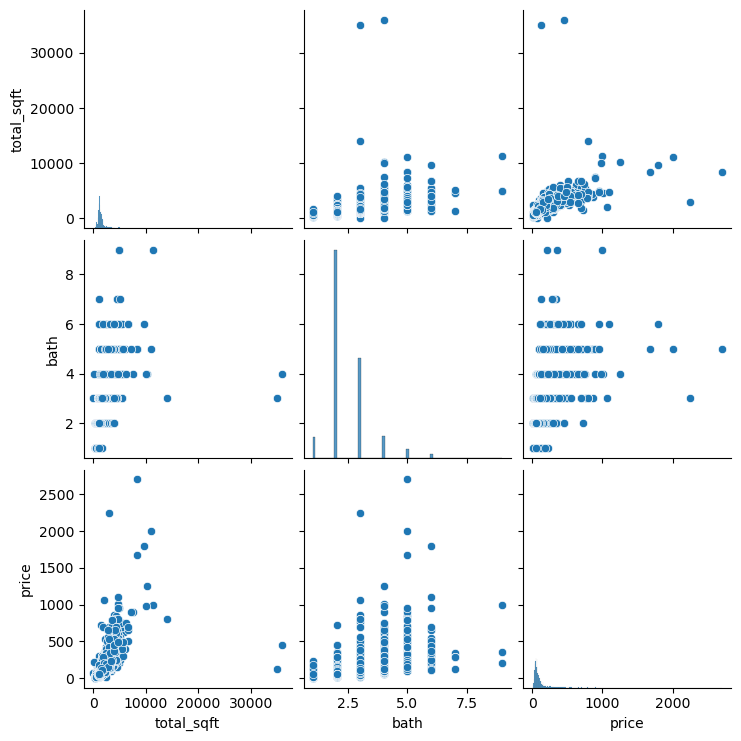

In [23]:
sns.pairplot(df[['total_sqft','bath','price']])
plt.show()

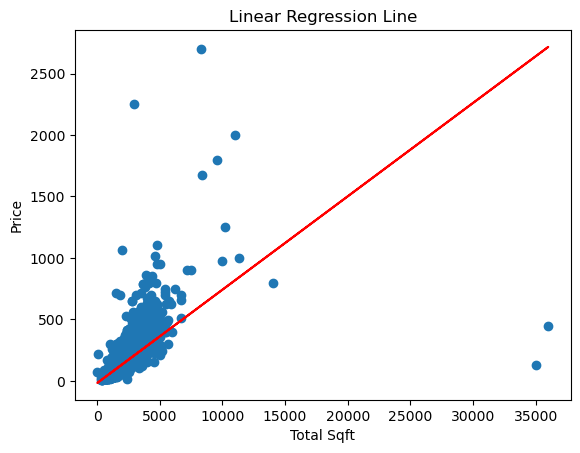

In [24]:
plt.scatter(df['total_sqft'], df['price'])

model_single = LinearRegression()
model_single.fit(df[['total_sqft']], df['price'])

plt.plot(df['total_sqft'], model_single.predict(df[['total_sqft']]), color='red')

plt.xlabel("Total Sqft")
plt.ylabel("Price")
plt.title("Linear Regression Line")

plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv(r"C:\Users\Nidhi\Downloads\stocks.csv")

print(df.head())
print(df.info())

  Ticker        Date        Open        High         Low       Close  \
0   AAPL  2023-02-07  150.639999  155.229996  150.639999  154.649994   
1   AAPL  2023-02-08  153.880005  154.580002  151.169998  151.919998   
2   AAPL  2023-02-09  153.779999  154.330002  150.419998  150.869995   
3   AAPL  2023-02-10  149.460007  151.339996  149.220001  151.009995   
4   AAPL  2023-02-13  150.949997  154.259995  150.919998  153.850006   

    Adj Close    Volume  
0  154.414230  83322600  
1  151.688400  64120100  
2  150.639999  56007100  
3  151.009995  57450700  
4  153.850006  62199000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-nul

In [6]:
df = df.dropna()

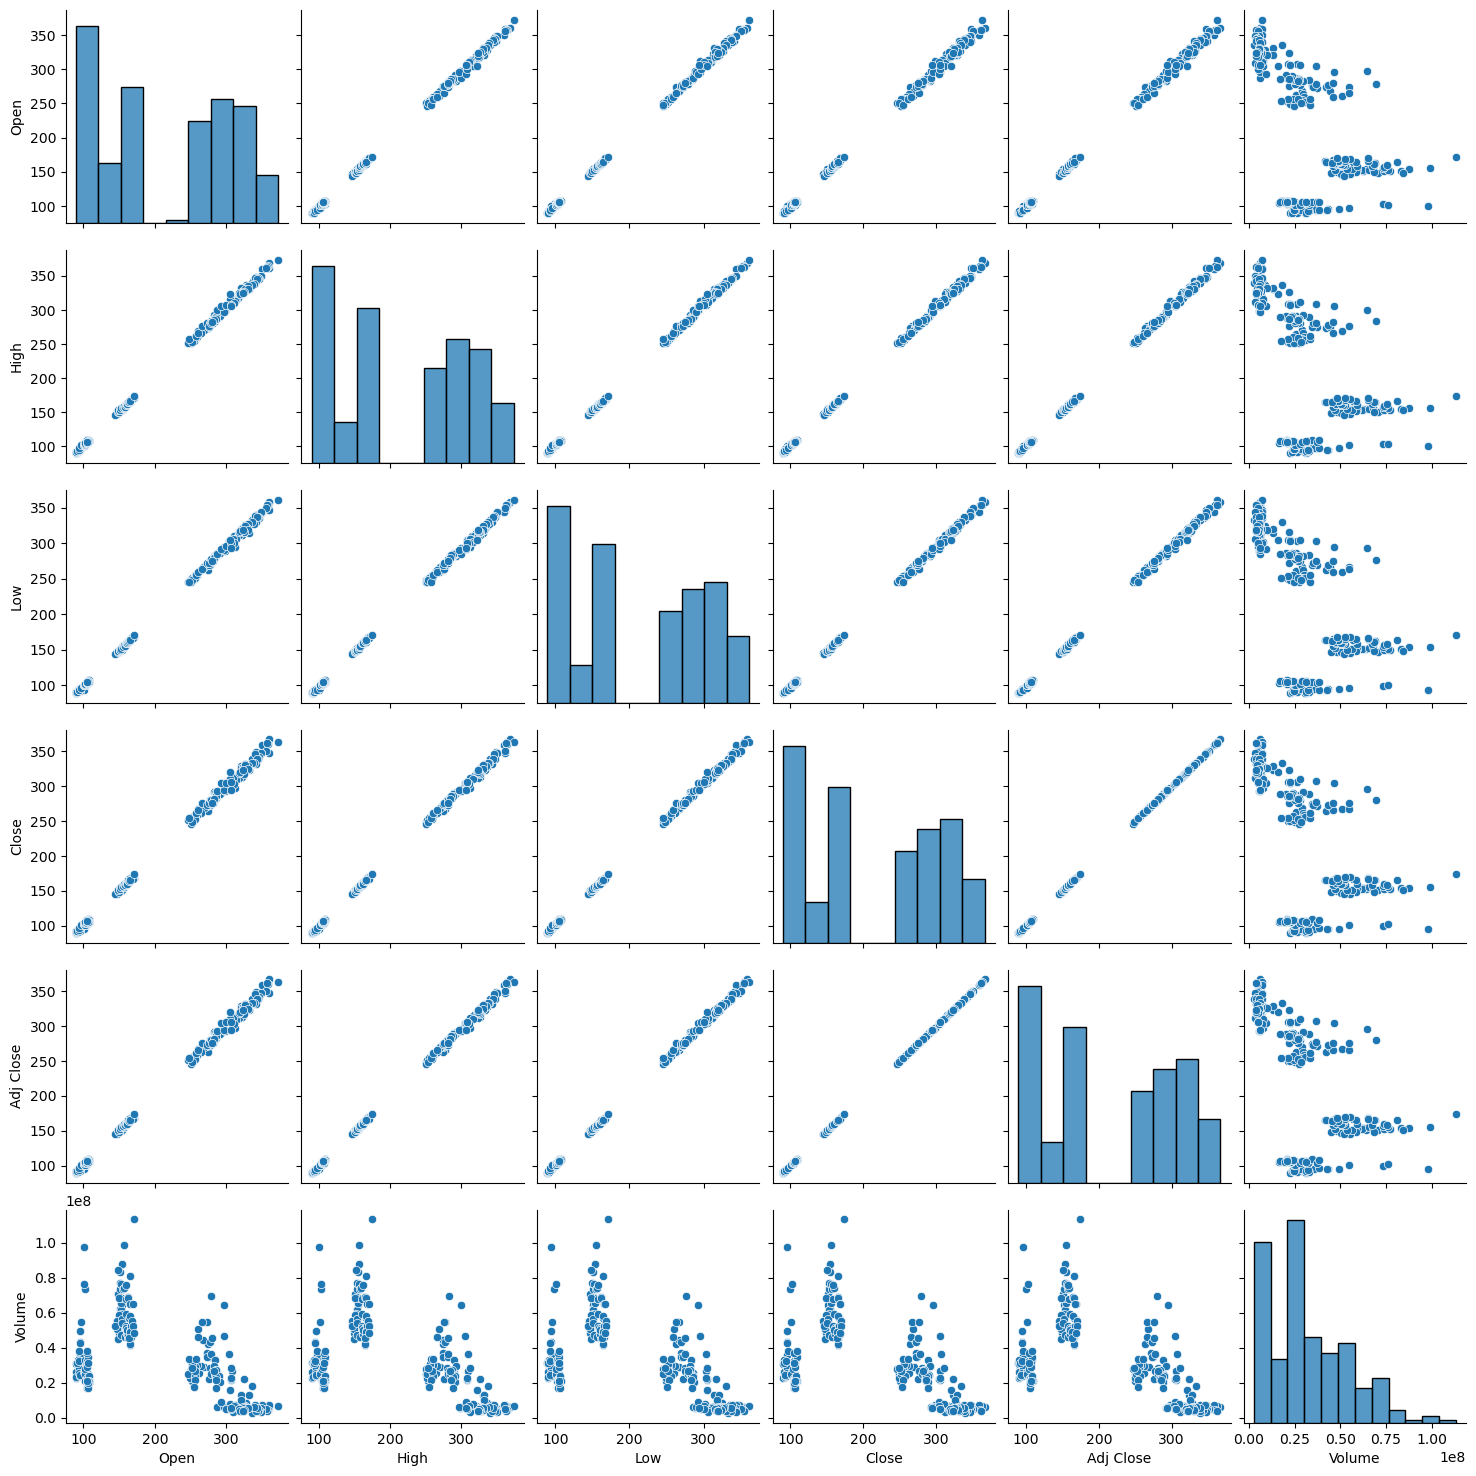

In [7]:
sns.pairplot(df)
plt.show()

In [8]:
X = df[['Open']]
y = df['Close']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train, y_train)

LinearRegression()

In [12]:
print("Model Score:", model.score(X_test, y_test))

Model Score: 0.9990261566083692


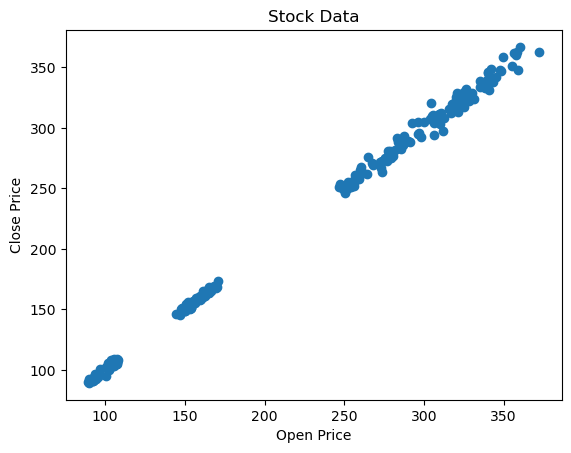

In [13]:
plt.scatter(X, y)
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Stock Data")
plt.show()

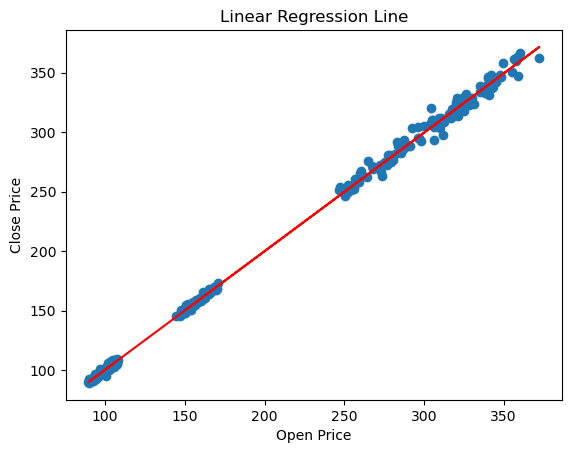

In [14]:
plt.scatter(X, y)

plt.plot(X, model.predict(X), color='red')

plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Linear Regression Line")

plt.show()